In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


## Data Preparation

In [5]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

categorical_columns = list(df.dtypes[df.dtypes == "str"].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(" ", "_")

In [6]:
tc = pd.to_numeric(df.totalcharges, errors="coerce")

In [7]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors="coerce")

In [8]:
df.totalcharges = df.totalcharges.fillna(0)

In [9]:
df[tc.isnull()][["customerid","totalcharges"]]

,customerid,totalcharges
488,4472-lvygi,0.0
753,3115-czmzd,0.0
936,5709-lvoeq,0.0
1082,4367-nuyao,0.0
1340,1371-dwpaz,0.0
3331,7644-omvmy,0.0
3826,3213-vvolg,0.0
4380,2520-sgtta,0.0
5218,2923-arzlg,0.0
6670,4075-wkniu,0.0


In [10]:
df.churn.head()

0     no
1     no
2    yes
3     no
4    yes
Name: churn, dtype: str

In [11]:
df.churn = (df.churn == "yes").astype(int)

## Setting up the validation framework

In [12]:
from sklearn.model_selection import train_test_split


In [13]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)


In [14]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)


In [15]:
len(df_train), len(df_val), len(df_test)


(4225, 1409, 1409)

In [16]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


In [17]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values



In [18]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

## EDA

In [19]:
df_full_train = df_full_train.reset_index(drop=True)

In [20]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [21]:
df_full_train.churn.mean()

np.float64(0.26996805111821087)

In [22]:
numerical = ["tenure","monthlycharges", "totalcharges"]

In [23]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [24]:
 categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
      'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

In [25]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## Feature Importance

### Churn Rate

In [26]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [27]:
churn_female = df_full_train[df_full_train.gender == "female"].churn.mean()
churn_female


np.float64(0.27682403433476394)

In [28]:
churn_male = df_full_train[df_full_train.gender == "male"].churn.mean()
churn_male

np.float64(0.2632135306553911)

In [29]:
global_churn = df_full_train.churn.mean()
global_churn

np.float64(0.26996805111821087)

In [30]:
churn_partner = df_full_train[df_full_train.partner == "yes"].churn.mean()

churn_partner

np.float64(0.20503330866025166)

In [31]:
churn_no_partner = df_full_train[df_full_train.partner == "no"].churn.mean()
churn_no_partner

np.float64(0.3298090040927694)

In [32]:
global_churn - churn_no_partner

np.float64(-0.05984095297455855)

### Risk Ratio

In [33]:
churn_no_partner / global_churn

np.float64(1.2216593879412643)

In [34]:
churn_partner / global_churn

np.float64(0.7594724924338315)

In [35]:
from IPython.display import display


In [36]:
for c in categorical:
    print(c)

    df_group = df_full_train.groupby(c).churn.agg(["mean","count"])

    df_group["diff"] = df_group["mean"] - global_churn

    df_group["risk"] = df_group["mean"] / global_churn

    display(df_group)
    
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


,mean,count,diff,risk
partner,,,,
no,0.329809,2932,0.059841,1.221659
yes,0.205033,2702,-0.064935,0.759472




dependents


,mean,count,diff,risk
dependents,,,,
no,0.313760,3968,0.043792,1.162212
yes,0.165666,1666,-0.104302,0.613651




phoneservice


,mean,count,diff,risk
phoneservice,,,,
no,0.241316,547,-0.028652,0.893870
yes,0.273049,5087,0.003081,1.011412




multiplelines


,mean,count,diff,risk
multiplelines,,,,
no,0.257407,2700,-0.012561,0.953474
no_phone_service,0.241316,547,-0.028652,0.893870
yes,0.290742,2387,0.020773,1.076948




internetservice


,mean,count,diff,risk
internetservice,,,,
dsl,0.192347,1934,-0.077621,0.712482
fiber_optic,0.425171,2479,0.155203,1.574895
no,0.077805,1221,-0.192163,0.288201




onlinesecurity


,mean,count,diff,risk
onlinesecurity,,,,
no,0.420921,2801,0.150953,1.559152
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.153226,1612,-0.116742,0.567570




onlinebackup


,mean,count,diff,risk
onlinebackup,,,,
no,0.404323,2498,0.134355,1.497672
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.217232,1915,-0.052736,0.804660




deviceprotection


,mean,count,diff,risk
deviceprotection,,,,
no,0.395875,2473,0.125907,1.466379
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.230412,1940,-0.039556,0.853480




techsupport


,mean,count,diff,risk
techsupport,,,,
no,0.418914,2781,0.148946,1.551717
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.159926,1632,-0.110042,0.592390




streamingtv


,mean,count,diff,risk
streamingtv,,,,
no,0.342832,2246,0.072864,1.269897
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.302723,2167,0.032755,1.121328




streamingmovies


,mean,count,diff,risk
streamingmovies,,,,
no,0.338906,2213,0.068938,1.255358
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.307273,2200,0.037305,1.138182




contract


,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


## Feature importance: Mutual information

In [37]:
from sklearn.metrics import mutual_info_score

In [38]:
mutual_info_score(
    df_full_train.churn,
    df_full_train.contract
)

0.0983203874041556

In [39]:
mutual_info_score(
    df_full_train.churn,
    df_full_train.gender
)

0.0001174846211139946

In [40]:
mutual_info_score(
    df_full_train.churn,
    df_full_train.partner
)

0.009967689095399745

In [41]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [42]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

## Feature importance: Correlation

In [43]:
df_full_train.tenure.max()

np.int64(72)

In [44]:
df_full_train[numerical].corrwith(df_full_train.churn).abs()

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

In [45]:
df_full_train[df_full_train.tenure <= 2].churn.mean()

np.float64(0.5953420669577875)

In [46]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <=  12) ].churn.mean()

np.float64(0.3994413407821229)

In [47]:
df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.17634908339788277)

In [48]:
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()

np.float64(0.08795411089866156)

In [49]:
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()

np.float64(0.18340943683409436)

In [50]:
df_full_train[df_full_train.monthlycharges > 50].churn.mean()

np.float64(0.32499341585462205)

## One-Hot Encoding

In [51]:
from sklearn.feature_extraction import DictVectorizer

In [52]:
dv = DictVectorizer(sparse=False)


In [53]:
train_dict = df_train[categorical + numerical].to_dict(orient= "records")

In [54]:
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')

X_val = dv.transform(val_dict)


## Logistic Regression

In [55]:
def sigmoid(z):
    return  1 / (1 + np.exp(-z))


In [56]:
def logistic_regression(xi):
    score = w0

    for j in range(len(w)):
        score = score * xi[j] * w[j]

    result = sigmoid(score)

    return result


## Training Logistic Regression

In [57]:
from sklearn.linear_model import LogisticRegression

In [58]:
model = LogisticRegression(solver = "lbfgs")

model.fit(X_train, y_train)


/Users/baranerkek/class/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [59]:
model.intercept_[0]

np.float64(-0.10902792548978092)

In [60]:
model.coef_[0].round(3)

array([ 0.475, -0.175, -0.408, -0.03 , -0.078,  0.063, -0.089, -0.081,
       -0.034, -0.073, -0.335,  0.316, -0.089,  0.004, -0.258,  0.141,
        0.009,  0.063, -0.089, -0.081,  0.266, -0.089, -0.284, -0.231,
        0.123, -0.166,  0.058, -0.087, -0.032,  0.07 , -0.059,  0.141,
       -0.249,  0.215, -0.12 , -0.089,  0.102, -0.071, -0.089,  0.052,
        0.213, -0.089, -0.232, -0.07 ,  0.   ])

In [61]:
y_pred_val = model.predict_proba(X_val)[:,1]

In [62]:
churn_decision_val = (y_pred_val >= 0.5)

In [63]:
df_val[churn_decision_val].customerid

3       8433-wxgna
8       3440-jpscl
11      2637-fkfsy
12      7228-omtpn
19      6711-fldfb
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 311, dtype: str

In [64]:
(y_val == churn_decision_val).mean()

np.float64(0.8034066713981547)

In [65]:
df_pred = pd.DataFrame()

df_pred["probability"] = y_pred_val

df_pred["prediciton"] = churn_decision_val.astype(int)

df_pred["actual"] = y_val

In [66]:
df_pred["correct"] = df_pred.prediciton == df_pred.actual

In [67]:
df_pred.correct.mean()

np.float64(0.8034066713981547)

## Using the model

In [68]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient="records")

In [69]:
dv = DictVectorizer(sparse=False)

X_full_train = dv.fit_transform(dicts_full_train)

In [70]:
y_full_train = df_full_train.churn.values

In [71]:
model = LogisticRegression(max_iter=1000)

model.fit(X_full_train, y_full_train)

/Users/baranerkek/class/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [72]:
dicts_test = df_test[categorical + numerical].to_dict(orient = "records")

In [73]:
X_test = dv.transform(dicts_test)

In [74]:
y_pred = model.predict_proba(X_test)[:,1]

In [75]:
churn_decision_test = (y_pred >= 0.5)

In [76]:
accuracy = (churn_decision_test == y_test).mean()
accuracy

np.float64(0.8105039034776437)

## Accuracy and Dummy Model

In [77]:
len(y_val)

1409

In [78]:
(y_val == churn_decision_val).mean()

np.float64(0.8034066713981547)

In [79]:
from sklearn.metrics import accuracy_score

accuracy_score(y_val, y_pred_val >= 0.5)

0.8034066713981547

In [80]:
thresholds = np.linspace(0,1,21)

scores = [] 

for t in thresholds:

    score = accuracy_score(y_val, y_pred_val >= t)
    

    print("%.2f %.3f" % (t,score))

    scores.append(score)



0.00 0.274
0.05 0.509
0.10 0.591
0.15 0.666
0.20 0.710
0.25 0.739
0.30 0.760
0.35 0.772
0.40 0.785
0.45 0.793
0.50 0.803
0.55 0.801
0.60 0.795
0.65 0.786
0.70 0.766
0.75 0.744
0.80 0.735
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


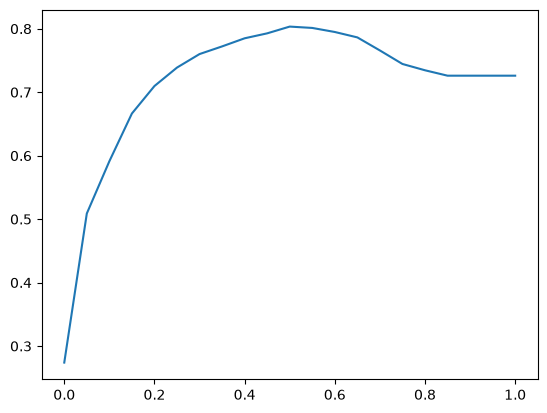

In [81]:
plt.plot(thresholds, scores)

In [82]:
from collections import Counter

In [83]:
Counter(y_pred_val >= 1.0)

Counter({np.False_: 1409})

In [84]:
1 - y_val.mean()

np.float64(0.7260468417317246)

## Confusion Table

In [85]:
actual_positive = ( y_val == 1)

actual_negative = ( y_val == 0)

In [86]:
t = 0.5

predict_positive = ( y_pred_val >= t )

predict_negative = ( y_pred_val < t )

In [87]:
tp = (predict_positive & actual_positive).sum()

tn = (predict_negative & actual_negative).sum()

In [88]:
fp = ( predict_positive & actual_negative).sum()

fn = ( predict_negative & actual_positive ).sum()

In [89]:
fp, fn

(np.int64(101), np.int64(176))

In [90]:
confusion_matrix = np.array([
    [tn, fp],

    [fn, tp]
])
confusion_matrix

array([[922, 101],
       [176, 210]])

## Precision and Recall

In [91]:
(tp + tn )/ (tp + tn + fp + fn)


np.float64(0.8034066713981547)

In [92]:
p = tp / ( tp + fp)
p


np.float64(0.6752411575562701)

In [93]:
tp + fp

np.int64(311)

In [94]:
r = tp / (tp + fn)
r

np.float64(0.5440414507772021)

In [95]:
tp + fn

np.int64(386)

## ROC Curves

### TPR AND FRP

In [96]:
tpr = tp / (tp + fn)
tpr

np.float64(0.5440414507772021)

In [97]:
fpr = fp / (fp+ tn)
fpr

np.float64(0.09872922776148582)

In [98]:
scores = []

thresholds2 = np.linspace(0,1,101)

for t in thresholds2 :
    actual_positive = ( y_val == 1)

    actual_negative = ( y_val == 0)

    predict_positive = ( y_pred_val >= t )

    predict_negative = ( y_pred_val < t )

    tp = (predict_positive & actual_positive).sum()

    tn = (predict_negative & actual_negative).sum()
 
    fp = ( predict_positive & actual_negative).sum()

    fn = ( predict_negative & actual_positive ).sum()

    scores.append((t, tp ,fp ,fn , tn))

In [99]:
columns = ["threshold","tp" ,"fp" ,"fn" , "tn"]

df_scores = pd.DataFrame(scores, columns=columns)

df_scores["tpr"] = df_scores.tp / ( df_scores.tp + df_scores.fn)
df_scores["fpr"] = df_scores.fp / (df_scores.fp + df_scores.tn)

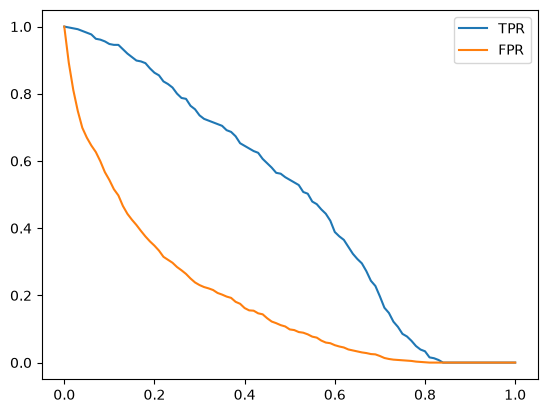

In [100]:
plt.plot(df_scores.threshold, df_scores["tpr"],  label= "TPR")

plt.plot(df_scores.threshold, df_scores["fpr"], label = "FPR")

plt.legend()

In [101]:
np.random.seed(1)

y_rand = np.random.uniform(0,1, size = len(y_val))

y_rand.round(3)

((y_rand >= 0.5) == y_val).mean()

np.float64(0.5017743080198722)

In [102]:
def tpr_fpr_dataframe(y_val, y_pred_val):
    scores = []

    thresholds2 = np.linspace(0,1,101)

    for t in thresholds2 :
        actual_positive = ( y_val == 1)

        actual_negative = ( y_val == 0)

        predict_positive = ( y_pred_val >= t )

        predict_negative = ( y_pred_val < t )

        tp = (predict_positive & actual_positive).sum()

        tn = (predict_negative & actual_negative).sum()
 
        fp = ( predict_positive & actual_negative).sum()

        fn = ( predict_negative & actual_positive ).sum()

        scores.append((t, tp ,fp ,fn , tn))

    columns = ["threshold","tp" ,"fp" ,"fn" , "tn"]

    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores["tpr"] = df_scores.tp / ( df_scores.tp + df_scores.fn)
    df_scores["fpr"] = df_scores.fp / (df_scores.fp + df_scores.tn)

    return df_scores

In [103]:
df_rand = tpr_fpr_dataframe(y_val,y_rand)

df_rand[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,347,923,39,100,0.898964,0.902248
20,0.2,307,822,79,201,0.795337,0.803519
30,0.3,276,724,110,299,0.715026,0.707722
40,0.4,237,624,149,399,0.613990,0.609971
50,0.5,202,518,184,505,0.523316,0.506354
60,0.6,161,409,225,614,0.417098,0.399804
70,0.7,121,302,265,721,0.313472,0.295210
80,0.8,78,206,308,817,0.202073,0.201369
90,0.9,40,101,346,922,0.103627,0.098729


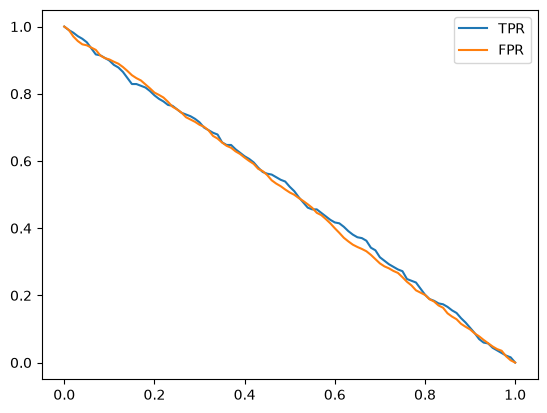

In [104]:
plt.plot(df_rand.threshold, df_rand["tpr"],  label= "TPR")

plt.plot(df_rand.threshold, df_rand["fpr"], label = "FPR")

plt.legend()

### Ideal Model

In [105]:
num_neg = (y_val == 0).sum()

num_pos = (y_val == 1).sum()

num_neg,num_pos

(np.int64(1023), np.int64(386))

In [106]:
y_ideal = np.repeat([0,1], [num_neg, num_pos])

y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

In [107]:
y_ideal_pred = np.linspace(0,1,len(y_val))

In [108]:
((y_ideal_pred >= 0.726) == y_ideal).mean()

np.float64(1.0)

In [109]:
df_ideal = tpr_fpr_dataframe(y_ideal,y_ideal_pred)

In [110]:
df_ideal[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,386,882,0,141,1.000000,0.862170
20,0.2,386,741,0,282,1.000000,0.724340
30,0.3,386,600,0,423,1.000000,0.586510
40,0.4,386,459,0,564,1.000000,0.448680
50,0.5,386,319,0,704,1.000000,0.311828
60,0.6,386,178,0,845,1.000000,0.173998
70,0.7,386,37,0,986,1.000000,0.036168
80,0.8,282,0,104,1023,0.730570,0.000000
90,0.9,141,0,245,1023,0.365285,0.000000


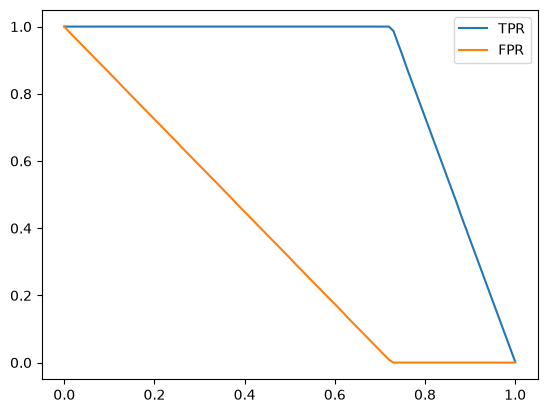

In [112]:
plt.plot(df_ideal.threshold, df_ideal["tpr"],  label= "TPR")

plt.plot(df_ideal.threshold, df_ideal["fpr"], label = "FPR")

plt.legend()

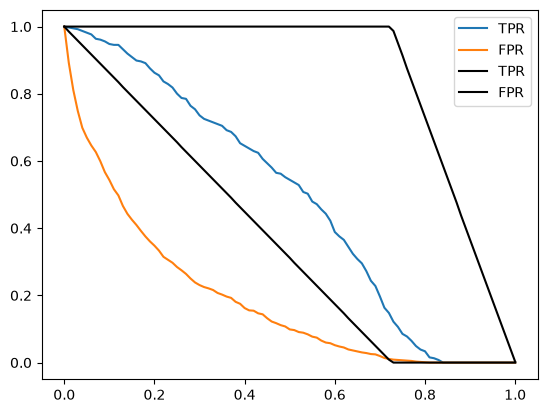

In [114]:
plt.plot(df_scores.threshold, df_scores["tpr"],  label= "TPR")

plt.plot(df_scores.threshold, df_scores["fpr"], label = "FPR")

#plt.plot(df_rand.threshold, df_rand["tpr"],  label= "TPR")

#plt.plot(df_rand.threshold, df_rand["fpr"], label = "FPR")

plt.plot(df_ideal.threshold, df_ideal["tpr"],  label= "TPR", color="black")

plt.plot(df_ideal.threshold, df_ideal["fpr"], label = "FPR", color ="black")

plt.legend()

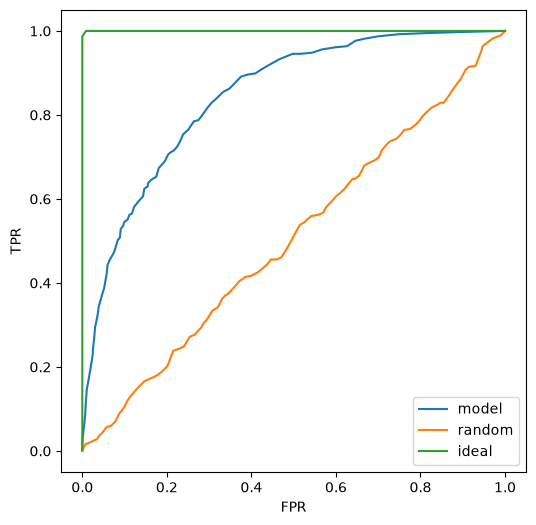

In [121]:
plt.figure(figsize=(6,6))


plt.plot(df_scores.fpr, df_scores.tpr, label = "model")

plt.plot(df_rand.fpr, df_rand.tpr, label = "random")

plt.plot(df_ideal.fpr, df_ideal.tpr, label = "ideal")

plt.xlabel("FPR")

plt.ylabel("TPR")

plt.legend()

In [123]:
from sklearn.metrics import roc_curve

In [127]:
fpr,tpr,thresholds = roc_curve(y_val,y_pred_val)

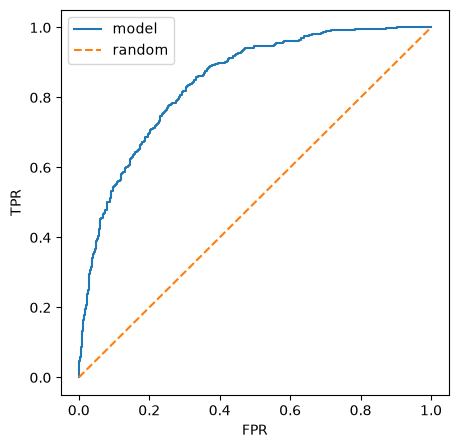

In [128]:
plt.figure(figsize=(5,5))


plt.plot(fpr, tpr, label = "model")
plt.plot([0,1], [0,1], label = "random", linestyle = "--")


plt.xlabel("FPR")
plt.ylabel("TPR")

plt.legend()

In [136]:
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

model = LogisticRegression(max_iter=1000)
model.fit(X_full_train, y_full_train)

/Users/baranerkek/class/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [137]:
import joblib

model_bundle = {
    "vectorizer": dv,
    "model": model
}

joblib.dump(model_bundle, "model.joblib")

['model.joblib']